# 12. Volatility Clustering

## Objective
Identify volatility regimes (Low/Medium/High), perform clustering-based volatility state discovery, engineer regime-aware features, and save an enriched, leakage-safe dataset for downstream RF/XGBoost/LSTM/Transformer training.

## 1) Imports & Configuration

In [1]:
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 220)

RANDOM_STATE = 42
N_CLUSTERS = 3

LOW_THRESHOLD = 0.0146
HIGH_THRESHOLD = 0.0192

REGIME_NAME_TO_ID = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
REGIME_ID_TO_NAME = {v: k for k, v in REGIME_NAME_TO_ID.items()}

## 2) Load Dataset

In [2]:
def resolve_input_path() -> Path:
    """Resolve final model dataset location from notebook or repo-root execution contexts."""
    candidates = [
        Path("..") / "Market_Data" / "processed" / "final_model_dataset.parquet",
        Path("Market_Data") / "processed" / "final_model_dataset.parquet",
        Path("ml_pipeline") / "Market_Data" / "processed" / "final_model_dataset.parquet",
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    raise FileNotFoundError("final_model_dataset.parquet not found in expected locations.")


def load_data(path: Path) -> pd.DataFrame:
    """Load and enforce time-series ordering assumptions."""
    data = pd.read_parquet(path)
    data["Date"] = pd.to_datetime(data["Date"], errors="raise")
    data["Ticker"] = data["Ticker"].astype(str)
    data = data.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    return data


input_path = resolve_input_path()
df = load_data(input_path)
baseline_columns = df.columns.tolist()

print(f"Input path: {input_path}")
print(f"Shape: {df.shape}")
print(f"Ticker count: {df['Ticker'].nunique()}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Columns: {len(df.columns)}")
display(pd.Series(df.columns, name="columns"))

Input path: C:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\processed\final_model_dataset.parquet
Shape: (63541, 156)
Ticker count: 96
Date range: 2023-04-18 to 2025-12-30
Columns: 156


0                     Date
1                   Ticker
2                     Open
3                     High
4                      Low
              ...         
151    return_roll_mean_20
152     return_roll_std_20
153            momentum_20
154    volume_roll_mean_20
155     volume_roll_std_20
Name: columns, Length: 156, dtype: object

## 3) Volatility Feature Analysis

Select a primary volatility feature and validate its statistical behavior.

Selected primary volatility column: Volatility_20


,value
min,0.003169
max,0.086057
mean,0.016879
std,0.008022


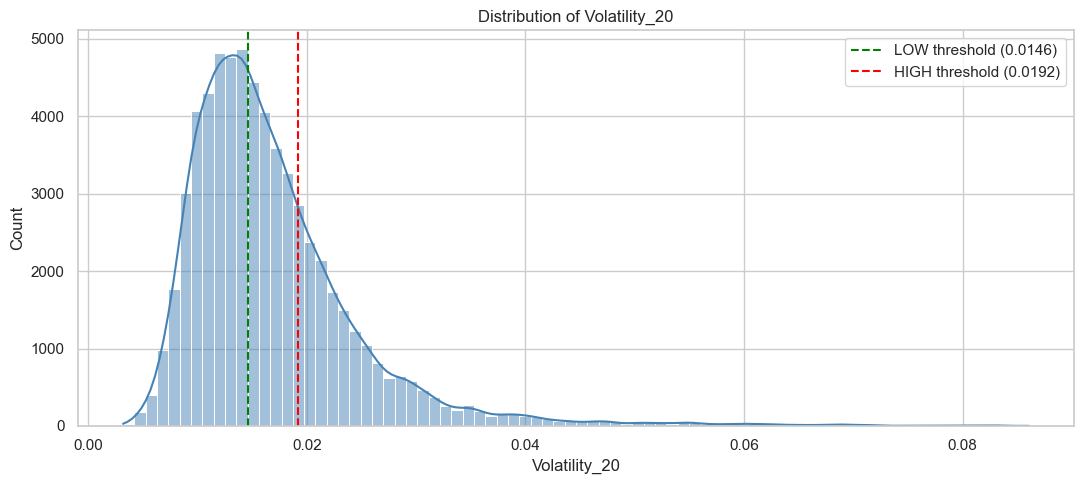

In [3]:
def select_primary_volatility_column(data: pd.DataFrame) -> str:
    """Pick primary volatility feature with preference order."""
    preferred = ["Volatility_20", "Volatility_50", "return_roll_std_20", "return_roll_std_10", "return_roll_std_5"]
    for col in preferred:
        if col in data.columns:
            return col
    candidates = [c for c in data.columns if "volatility" in c.lower() or "roll_std" in c.lower()]
    if candidates:
        return candidates[0]
    raise ValueError("No volatility feature found in dataset.")


vol_col = select_primary_volatility_column(df)
print(f"Selected primary volatility column: {vol_col}")

vol_stats = df[vol_col].agg(["min", "max", "mean", "std"]).to_frame(name="value")
display(vol_stats)

assert np.isfinite(df[vol_col]).all(), f"Non-finite values detected in {vol_col}."
assert (df[vol_col] >= 0).all(), f"Negative values found in {vol_col}; expected non-negative volatility."

plt.figure(figsize=(11, 5))
sns.histplot(df[vol_col], bins=80, kde=True, color="steelblue")
plt.axvline(LOW_THRESHOLD, color="green", linestyle="--", linewidth=1.5, label=f"LOW threshold ({LOW_THRESHOLD})")
plt.axvline(HIGH_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"HIGH threshold ({HIGH_THRESHOLD})")
plt.title(f"Distribution of {vol_col}")
plt.legend()
plt.tight_layout()
plt.show()

## 4) Rule-Based Volatility Regimes

Threshold-based regime assignment from EDA:
- LOW: volatility < 0.0146
- MEDIUM: 0.0146 <= volatility <= 0.0192
- HIGH: volatility > 0.0192

In [4]:
def create_regime_labels(data: pd.DataFrame, volatility_column: str) -> pd.DataFrame:
    """Create rule-based volatility regime labels and encoded IDs."""
    out = data.copy()
    conditions = [
        out[volatility_column] < LOW_THRESHOLD,
        out[volatility_column].between(LOW_THRESHOLD, HIGH_THRESHOLD, inclusive="both"),
        out[volatility_column] > HIGH_THRESHOLD,
    ]
    choices = [REGIME_NAME_TO_ID["LOW"], REGIME_NAME_TO_ID["MEDIUM"], REGIME_NAME_TO_ID["HIGH"]]
    out["volatility_regime"] = pd.Series(np.select(conditions, choices, default=np.nan), index=out.index).astype("Int64")
    out["volatility_regime_label"] = out["volatility_regime"].map(REGIME_ID_TO_NAME)
    return out


df = create_regime_labels(df, vol_col)

assert df["volatility_regime"].isin([0, 1, 2]).all(), "Invalid values found in volatility_regime."

regime_dist = df["volatility_regime_label"].value_counts().rename_axis("regime").reset_index(name="count")
regime_dist["pct"] = (regime_dist["count"] / regime_dist["count"].sum() * 100).round(2)
print("Overall rule-based regime distribution")
display(regime_dist)

per_ticker_regime = (
    df.pivot_table(index="Ticker", columns="volatility_regime_label", values=vol_col, aggfunc="count", fill_value=0)
    .reset_index()
)
print("Per-ticker regime distribution (counts)")
display(per_ticker_regime.head(15))

Overall rule-based regime distribution


,regime,count,pct
0,LOW,29339,46.17
1,HIGH,17608,27.71
2,MEDIUM,16594,26.12


Per-ticker regime distribution (counts)


volatility_regime_label,Ticker,HIGH,LOW,MEDIUM
0,ABB,297,174,198
1,ADANIENSOL,327,80,105
2,ADANIENT,345,161,163
3,ADANIGREEN,453,84,132
4,ADANIPORTS,248,239,182
5,ADANIPOWER,464,67,138
6,AMBUJACEM,138,282,249
7,APOLLOHOSP,44,462,163
8,ASIANPAINT,33,576,60
9,AXISBANK,53,483,133


## 5) Volatility Clustering (K-Means)

Use only contemporaneous volatility-related features (no future information), standardize them, and fit K-Means with k=3.

In [5]:
def get_volatility_feature_columns(data: pd.DataFrame, primary_col: str) -> List[str]:
    """Select volatility-related features for clustering without using future-derived variables."""
    selected = [primary_col]
    patterns = [
        "Volatility_50", "Volatility_20_lag_1", "Volatility_20_lag_2", "Volatility_20_lag_3",
        "Volatility_50_lag_1", "Volatility_50_lag_2", "Volatility_50_lag_3",
        "return_roll_std_5", "return_roll_std_10", "return_roll_std_20",
    ]
    for col in patterns:
        if col in data.columns and col not in selected:
            selected.append(col)

    # Fallback generic inclusion when engineered volatility columns exist.
    if len(selected) == 1:
        for col in data.columns:
            cl = col.lower()
            if ("volatility" in cl or "roll_std" in cl) and col not in selected:
                selected.append(col)

    return selected


def perform_clustering(data: pd.DataFrame, cluster_features: List[str], n_clusters: int = 3) -> Tuple[pd.DataFrame, StandardScaler, KMeans, pd.DataFrame, float]:
    """Fit standardized K-Means and append raw cluster labels."""
    out = data.copy()
    X = out[cluster_features].copy()
    assert X.isna().sum().sum() == 0, "NaNs found in clustering features."

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
    out["volatility_cluster"] = kmeans.fit_predict(X_scaled)

    centers_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_features)
    centers_original = pd.DataFrame(scaler.inverse_transform(centers_scaled), columns=cluster_features)
    centers_original["cluster_id"] = range(n_clusters)

    sil = silhouette_score(X_scaled, out["volatility_cluster"])
    return out, scaler, kmeans, centers_original, float(sil)


cluster_cols = get_volatility_feature_columns(df, vol_col)
print("Clustering features:")
print(cluster_cols)

df, scaler, kmeans_model, cluster_centers, kmeans_silhouette = perform_clustering(df, cluster_cols, n_clusters=N_CLUSTERS)
print(f"K-Means silhouette score: {kmeans_silhouette:.4f}")
display(cluster_centers.sort_values(vol_col).reset_index(drop=True))

Clustering features:
['Volatility_20', 'Volatility_50', 'Volatility_20_lag_1', 'Volatility_20_lag_2', 'Volatility_20_lag_3', 'Volatility_50_lag_1', 'Volatility_50_lag_2', 'Volatility_50_lag_3', 'return_roll_std_5', 'return_roll_std_10', 'return_roll_std_20']
K-Means silhouette score: 0.4378


,Volatility_20,Volatility_50,Volatility_20_lag_1,Volatility_20_lag_2,Volatility_20_lag_3,Volatility_50_lag_1,Volatility_50_lag_2,Volatility_50_lag_3,return_roll_std_5,return_roll_std_10,return_roll_std_20,cluster_id
0,0.012534,0.013436,0.012501,0.012531,0.012585,0.013445,0.013475,0.013512,0.011410,0.012041,0.012501,0
1,0.021241,0.021653,0.021263,0.021249,0.021233,0.021664,0.021666,0.021665,0.019757,0.020769,0.021263,1
2,0.039357,0.035983,0.039714,0.039564,0.039168,0.035967,0.035767,0.035505,0.034813,0.037923,0.039714,2


## 6) Cluster Evaluation & Interpretation

Interpret cluster IDs as LOW/MEDIUM/HIGH by ordering clusters on mean primary volatility.

In [6]:
def map_clusters_to_regimes(data: pd.DataFrame, volatility_column: str) -> Tuple[pd.DataFrame, Dict[int, int]]:
    """Map arbitrary cluster IDs to ordered regime IDs using volatility means."""
    out = data.copy()
    cluster_mean = out.groupby("volatility_cluster")[volatility_column].mean().sort_values()
    ordered_cluster_ids = cluster_mean.index.tolist()
    mapping = {
        ordered_cluster_ids[0]: REGIME_NAME_TO_ID["LOW"],
        ordered_cluster_ids[1]: REGIME_NAME_TO_ID["MEDIUM"],
        ordered_cluster_ids[2]: REGIME_NAME_TO_ID["HIGH"],
    }
    out["vol_cluster_label"] = out["volatility_cluster"].map(mapping).astype("Int64")
    out["vol_cluster_regime_name"] = out["vol_cluster_label"].map(REGIME_ID_TO_NAME)
    return out, mapping


df, cluster_to_regime_map = map_clusters_to_regimes(df, vol_col)

cluster_dist = df["volatility_cluster"].value_counts().sort_index().rename_axis("cluster_id").reset_index(name="count")
cluster_dist["pct"] = (cluster_dist["count"] / cluster_dist["count"].sum() * 100).round(2)
print("Raw cluster distribution")
display(cluster_dist)

comparison_ct = pd.crosstab(df["volatility_regime_label"], df["vol_cluster_regime_name"], margins=True)
print("Rule-based regime vs interpreted cluster regime")
display(comparison_ct)

cluster_vol_summary = df.groupby("volatility_cluster")[vol_col].agg(["mean", "std", "min", "max", "count"]).sort_values("mean")
display(cluster_vol_summary)

print("Cluster -> Regime mapping:")
print(cluster_to_regime_map)

Raw cluster distribution


,cluster_id,count,pct
0,0,38829,61.11
1,1,21352,33.60
2,2,3360,5.29


Rule-based regime vs interpreted cluster regime


vol_cluster_regime_name,HIGH,LOW,MEDIUM,All
volatility_regime_label,,,,
HIGH,3329,378,13901,17608
LOW,7,28532,800,29339
MEDIUM,24,9919,6651,16594
All,3360,38829,21352,63541


,mean,std,min,max,count
volatility_cluster,,,,,
0,0.012534,0.003064,0.003169,0.029515,38829
1,0.021242,0.004351,0.007663,0.055463,21352
2,0.039363,0.011980,0.010401,0.086057,3360


Cluster -> Regime mapping:
{0: 0, 1: 1, 2: 2}


### Optional Advanced: Gaussian Mixture Model and Transition Diagnostics

In [7]:
def optional_gmm_clustering(data: pd.DataFrame, cluster_features: List[str], n_components: int = 3) -> Tuple[pd.Series, float]:
    """Fit optional GMM on the same standardized volatility feature space."""
    X = data[cluster_features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    gmm = GaussianMixture(n_components=n_components, random_state=RANDOM_STATE)
    labels = pd.Series(gmm.fit_predict(X_scaled), index=data.index, name="volatility_cluster_gmm")
    sil = silhouette_score(X_scaled, labels)
    return labels, float(sil)


gmm_labels, gmm_silhouette = optional_gmm_clustering(df, cluster_cols, n_components=N_CLUSTERS)
df["volatility_cluster_gmm"] = gmm_labels
print(f"GMM silhouette score: {gmm_silhouette:.4f}")
display(df["volatility_cluster_gmm"].value_counts().sort_index().rename_axis("gmm_cluster").reset_index(name="count"))

transition_matrix = pd.crosstab(
    df.groupby("Ticker")["volatility_regime"].shift(1),
    df["volatility_regime"],
    normalize="index"
).fillna(0)
print("Regime transition matrix (P(current | previous))")
display(transition_matrix)

regime_duration_stats = (
    df.assign(prev=df.groupby("Ticker")["volatility_regime"].shift(1))
      .assign(change=lambda x: (x["volatility_regime"] != x["prev"]).fillna(True).astype(int))
      .assign(spell_id=lambda x: x.groupby("Ticker")["change"].cumsum())
      .groupby(["Ticker", "volatility_regime", "spell_id"]).size()
      .reset_index(name="duration")
      .groupby("volatility_regime")["duration"].agg(["mean", "median", "max", "count"])
)
print("Regime duration statistics")
display(regime_duration_stats)

GMM silhouette score: 0.0489


,gmm_cluster,count
0,0,31683
1,1,26081
2,2,5777


Regime transition matrix (P(current | previous))


volatility_regime,0,1,2
volatility_regime,,,
0,0.952941,0.045009,0.002051
1,0.080142,0.862751,0.057107
2,0.004375,0.053690,0.941935


Regime duration statistics


,mean,median,max,count
volatility_regime,,,,
0,20.164261,7.0,372,1455
1,7.255794,5.0,61,2287
2,17.111759,9.0,327,1029


## 7) Regime Feature Engineering

Create persistence, change, and lagged regime/cluster features using ticker-wise operations only.

In [8]:
def engineer_regime_features(data: pd.DataFrame) -> pd.DataFrame:
    """Create regime persistence/change and lagged categorical-state features."""
    out = data.copy()
    out = out.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    g = out.groupby("Ticker", sort=False)

    # Regime change from previous day (within ticker).
    prev_regime = g["volatility_regime"].shift(1)
    out["regime_change"] = (out["volatility_regime"] != prev_regime).fillna(True).astype(int)
    out.loc[prev_regime.isna(), "regime_change"] = 0

    # Regime persistence (consecutive days in same regime).
    out["regime_block_id"] = g["regime_change"].cumsum()
    out["regime_persistence"] = out.groupby(["Ticker", "regime_block_id"], sort=False).cumcount() + 1

    # Lag features for regime and cluster labels.
    out["regime_lag_1"] = g["volatility_regime"].shift(1)
    out["regime_lag_2"] = g["volatility_regime"].shift(2)
    out["cluster_lag_1"] = g["vol_cluster_label"].shift(1)
    out["cluster_lag_2"] = g["vol_cluster_label"].shift(2)

    # Keep only model-relevant engineered columns.
    out = out.drop(columns=["regime_block_id"])
    return out


df = engineer_regime_features(df)
new_regime_cols = [
    "volatility_regime", "volatility_regime_label",
    "volatility_cluster", "vol_cluster_label", "vol_cluster_regime_name", "volatility_cluster_gmm",
    "regime_change", "regime_persistence",
    "regime_lag_1", "regime_lag_2", "cluster_lag_1", "cluster_lag_2",
]
print("Engineered regime columns added:")
print([c for c in new_regime_cols if c in df.columns])

Engineered regime columns added:
['volatility_regime', 'volatility_regime_label', 'volatility_cluster', 'vol_cluster_label', 'vol_cluster_regime_name', 'volatility_cluster_gmm', 'regime_change', 'regime_persistence', 'regime_lag_1', 'regime_lag_2', 'cluster_lag_1', 'cluster_lag_2']


## 8) Visual Validation

Inspect volatility/regime behavior globally and on sample tickers.

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_18400\2256203167.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="volatility_regime_label", y=vol_col, order=["LOW", "MEDIUM", "HIGH"], palette="Set2")


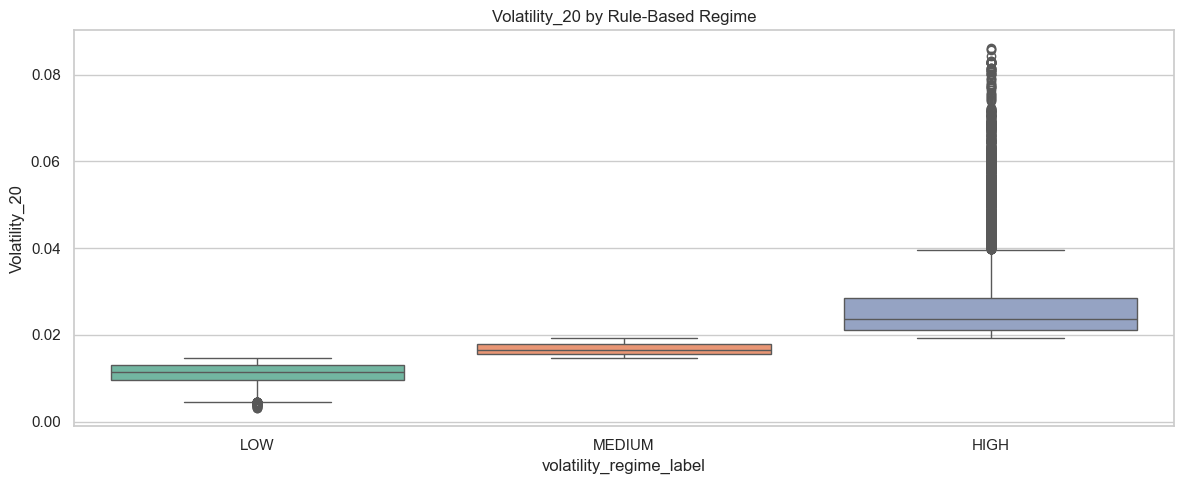

Sample tickers for time-series visualization: ['NIFTY50', 'UPL', 'MAZDOCK']


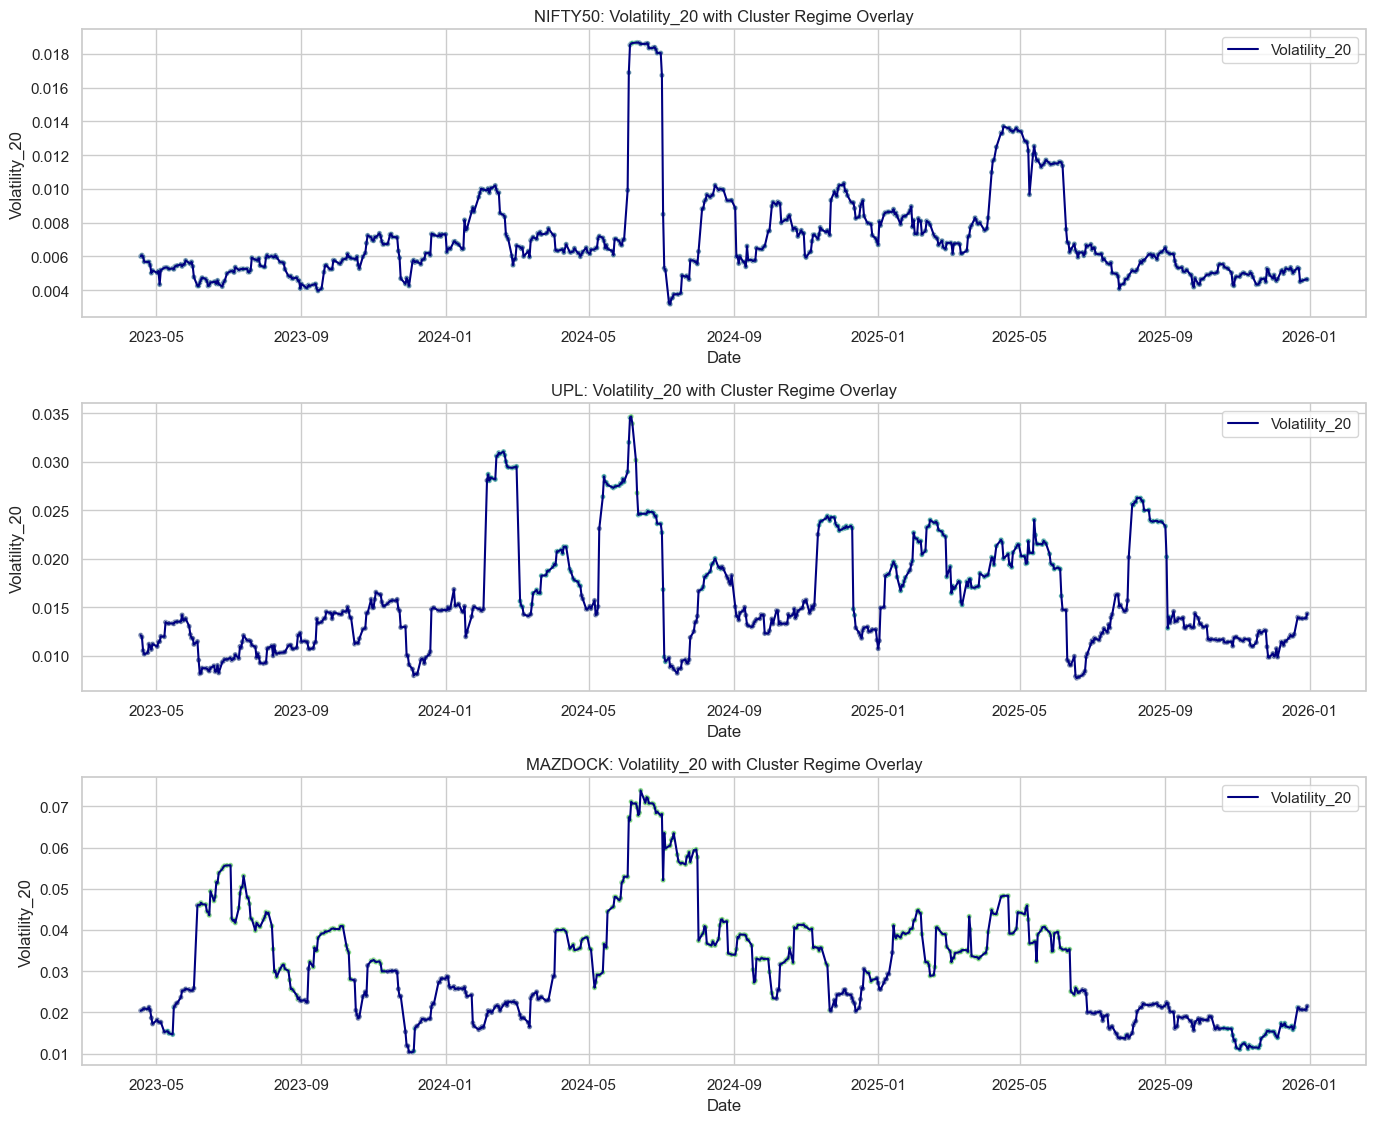

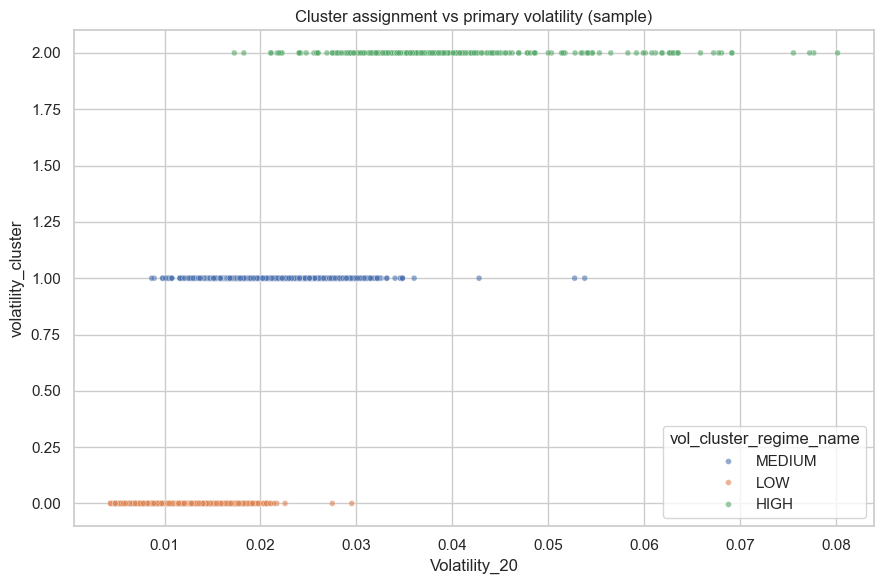

In [9]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="volatility_regime_label", y=vol_col, order=["LOW", "MEDIUM", "HIGH"], palette="Set2")
plt.title(f"{vol_col} by Rule-Based Regime")
plt.tight_layout()
plt.show()

ticker_mean_vol = df.groupby("Ticker")[vol_col].mean().sort_values()
ticker_index = ticker_mean_vol.index.tolist()
mid_idx = len(ticker_index) // 2
sample_tickers = [ticker_index[0], ticker_index[mid_idx], ticker_index[-1]]
print(f"Sample tickers for time-series visualization: {sample_tickers}")

fig, axes = plt.subplots(len(sample_tickers), 1, figsize=(14, 3.8 * len(sample_tickers)), sharex=False)
if len(sample_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, sample_tickers):
    sub = df[df["Ticker"] == ticker]
    sns.lineplot(data=sub, x="Date", y=vol_col, ax=ax, color="navy", label=vol_col)
    sns.scatterplot(data=sub, x="Date", y=vol_col, hue="vol_cluster_regime_name", palette="viridis", s=14, alpha=0.8, ax=ax, legend=False)
    ax.set_title(f"{ticker}: {vol_col} with Cluster Regime Overlay")

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=RANDOM_STATE), x=vol_col, y="volatility_cluster", hue="vol_cluster_regime_name", alpha=0.6, s=18)
plt.title("Cluster assignment vs primary volatility (sample)")
plt.tight_layout()
plt.show()

## 9) Final Dataset Validation

Assert data integrity after regime feature engineering.

In [10]:
def validate_dataset(data: pd.DataFrame) -> pd.DataFrame:
    """Validate no leakage-breaking artifacts and consistent sorting/labels."""
    out = data.copy()
    out = out.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    # Lag features naturally introduce NaN at the start of each ticker. Fill safely with current regime.
    out["regime_lag_1"] = out["regime_lag_1"].fillna(out["volatility_regime"]).astype(int)
    out["regime_lag_2"] = out["regime_lag_2"].fillna(out["regime_lag_1"]).astype(int)
    out["cluster_lag_1"] = out["cluster_lag_1"].fillna(out["vol_cluster_label"]).astype(int)
    out["cluster_lag_2"] = out["cluster_lag_2"].fillna(out["cluster_lag_1"]).astype(int)

    assert out.isna().sum().sum() == 0, "NaNs present after volatility feature engineering."
    assert out.duplicated(subset=["Date", "Ticker"]).sum() == 0, "Duplicate (Date, Ticker) rows detected."
    assert out.groupby("Ticker")["Date"].apply(lambda s: s.is_monotonic_increasing).all(), "Date order not preserved within ticker."
    assert out["volatility_regime"].isin([0, 1, 2]).all(), "Invalid values in volatility_regime."
    assert out["vol_cluster_label"].isin([0, 1, 2]).all(), "Invalid values in vol_cluster_label."
    return out


df_final = validate_dataset(df)
print("Validation passed.")
print(f"Validated shape: {df_final.shape}")

Validation passed.
Validated shape: (63541, 168)


## 10) Save Dataset

In [13]:
def resolve_output_path() -> Path:
    """Resolve output path for enriched volatility dataset."""
    candidates = [
        Path("..") / "Market_Data" / "processed" / "final_model_dataset_with_volatility.parquet",
        Path("Market_Data") / "processed" / "final_model_dataset_with_volatility.parquet",
        Path("ml_pipeline") / "Market_Data" / "processed" / "final_model_dataset_with_volatility.parquet",
    ]
    return candidates[0]


output_path = resolve_output_path()
output_path.parent.mkdir(parents=True, exist_ok=True)
df_final.to_parquet(output_path, index=False)
## csv for easier inspection and compatibility with other tools
df_final.to_csv(output_path.with_suffix(".csv"), index=False)

assert output_path.exists(), "Output file was not created."
print(f"Saved dataset: {output_path.resolve()}")

Saved dataset: C:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\processed\final_model_dataset_with_volatility.parquet


## 11) Summary

In [14]:
def summary_report(data: pd.DataFrame, baseline_columns: List[str]) -> None:
    """Print final concise summary for volatility enrichment stage."""
    new_cols = [c for c in data.columns if c not in baseline_columns]

    print("Final volatility-enriched dataset summary")
    print("-" * 65)
    print(f"Final shape: {data.shape}")
    print(f"New feature count: {len(new_cols)}")
    print(f"Ticker count: {data['Ticker'].nunique()}")
    print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")

    print("\nRule-based regime distribution:")
    print(data["volatility_regime_label"].value_counts(normalize=True).mul(100).round(2).to_string())

    print("\nCluster-based regime distribution:")
    print(data["vol_cluster_regime_name"].value_counts(normalize=True).mul(100).round(2).to_string())

    print("\nRaw cluster distribution:")
    print(data["volatility_cluster"].value_counts(normalize=True).mul(100).round(2).sort_index().to_string())

    print("\nNew columns list:")
    print(new_cols)


summary_report(df_final, baseline_columns=baseline_columns)

Final volatility-enriched dataset summary
-----------------------------------------------------------------
Final shape: (63541, 168)
New feature count: 12
Ticker count: 96
Date range: 2023-04-18 to 2025-12-30

Rule-based regime distribution:
volatility_regime_label
LOW       46.17
HIGH      27.71
MEDIUM    26.12

Cluster-based regime distribution:
vol_cluster_regime_name
LOW       61.11
MEDIUM    33.60
HIGH       5.29

Raw cluster distribution:
volatility_cluster
0    61.11
1    33.60
2     5.29

New columns list:
['volatility_regime', 'volatility_regime_label', 'volatility_cluster', 'vol_cluster_label', 'vol_cluster_regime_name', 'volatility_cluster_gmm', 'regime_change', 'regime_persistence', 'regime_lag_1', 'regime_lag_2', 'cluster_lag_1', 'cluster_lag_2']
